In [115]:
import numpy as np
import pandas as pd
from pylab import plt, mpl
from sklearn.metrics import accuracy_score, f1_score
import os
import talib as ta
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight

frequency = "1d"
window_pred = 1

# Cargar los datos para esta frecuencia
AVAXUSDT = pd.read_csv('Datos/AVAXUSDT_1d_01-01-2016_01-01-2025.csv', index_col='timestamp')
XRPUSDT = pd.read_csv('Datos/XRPUSDT_1d_01-01-2016_01-01-2025.csv', index_col='timestamp')
ADAUSDT = pd.read_csv('Datos/ADAUSDT_1d_01-01-2016_01-01-2025.csv', index_col='timestamp')
BTCUSDT = pd.read_csv('Datos/BTCUSDT_1d_01-01-2016_01-01-2025.csv', index_col='timestamp')
ETHUSDT = pd.read_csv('Datos/ETHUSDT_1d_01-01-2016_01-01-2025.csv', index_col='timestamp')
LINKUSDT = pd.read_csv('Datos/LINKUSDT_1d_01-01-2016_01-01-2025.csv', index_col='timestamp')
SOLUSDT = pd.read_csv('Datos/SOLUSDT_1d_01-01-2016_01-01-2025.csv', index_col='timestamp')
LTCUSDT = pd.read_csv('Datos/LTCUSDT_1d_01-01-2016_01-01-2025.csv', index_col='timestamp')
TRXUSDT = pd.read_csv('Datos/TRXUSDT_1d_01-01-2016_01-01-2025.csv', index_col='timestamp')
data = pd.DataFrame() 

data['AVAXUSDT'] = AVAXUSDT[['close']]
data['XRPUSDT'] = XRPUSDT[['close']]
data['ADAUSDT'] = ADAUSDT[['close']]
data['BTCUSDT'] = BTCUSDT[['close']]
data['ETHUSDT'] = ETHUSDT[['close']]
data['LINKUSDT'] = LINKUSDT[['close']]
data['SOLUSDT'] = SOLUSDT[['close']]
data['LTCUSDT'] = LTCUSDT[['close']]
data['TRXUSDT'] = TRXUSDT[['close']]
data.index = pd.to_datetime(data.index)
data.head()

,AVAXUSDT,XRPUSDT,ADAUSDT,BTCUSDT,ETHUSDT,LINKUSDT,SOLUSDT,LTCUSDT,TRXUSDT
timestamp,,,,,,,,,
2020-09-22,5.3193,0.23302,0.08146,10529.61,344.21,8.7401,2.9082,44.47,0.02499
2020-09-23,3.5350,0.22164,0.07663,10241.46,320.72,7.6364,2.8548,42.96,0.02486
2020-09-24,4.6411,0.23276,0.08254,10736.32,348.97,9.8700,3.1433,44.92,0.02625
2020-09-25,4.7134,0.24154,0.09693,10686.67,351.92,10.7279,3.1937,46.02,0.02714
2020-09-26,4.5200,0.24153,0.09547,10728.60,353.92,10.3169,3.1287,46.03,0.02718


In [116]:
def save_results(model, ric, acc, sample, frequency=frequency):
    # Verificar si el archivo ya existe
    file_name = f'accuracy_results_{frequency}_charac.csv'

    # Si el archivo existe, leer los datos previos, si no, crear un nuevo DataFrame vacío
    if os.path.exists(file_name):
        df_results = pd.read_csv(file_name)
    else:
        df_results = pd.DataFrame(columns=['Model', 'Asset', 'Accuracy', 'What'])

    # Agregar la nueva fila con los resultados
    new_row = pd.DataFrame([[model, ric, acc, sample]], columns=['Model', 'Asset', 'Accuracy', 'What'])
    df_results = pd.concat([df_results, new_row], ignore_index=True)

    # Guardar los resultados acumulados
    df_results.to_csv(file_name, index=False) 

In [117]:
def charact_lags(data, ric, lags, window_pred, window=30):
    cols = []
    df = pd.DataFrame(data[ric])
    df['r'] = np.log(df / df.shift()) #retornos
    df['sma'] = df[ric].rolling(window).mean()  #media movil de la ventana
    df['min'] = df[ric].rolling(window).min() #mínimo de la ventana
    df['max'] = df[ric].rolling(window).max() #máximo de la ventana
    df['mom'] = df[ric].pct_change(window) #momentum de la ventana pct_change(12)
    df['vol'] = df['r'].rolling(window).std() #volatilidad de la ventana
    df['rsi'] = ta.RSI(df[ric], timeperiod=window) #rsi de la ventana
    df['atr'] = ta.ATR(df[ric], df[ric], df[ric], timeperiod=window) #atr de la ventana
    df = df.iloc[:-window_pred]
    df['d'] = np.where(df[ric].shift(-window_pred) > df[ric], 1, 0) # columna binaria, 0 si los precios bajarán, 1 si subirán
    features = [ric, 'r', 'sma', 'min', 'max', 'mom', 'vol', 'rsi', 'atr']
    for f in features:
        for lag in range(1, lags + 1):
            col = f'{f}_lag_{lag}'
            df[col] = df[f].shift(lag)
            cols.append(col)
    return df, cols

lags = 5

dfs = {}
results = []
for ric in data:
    df, cols = charact_lags(data, ric, lags, window_pred)
    dfs[ric] = df, cols
    p = df['d'].value_counts(normalize=True) 
    results.append({
        'ric': ric,
        '0': p[0], 
        '1': p[1]}
        )
results_df = pd.DataFrame(results)
results_df 

,ric,0,1
0,AVAXUSDT,0.503201,0.496799
1,XRPUSDT,0.492318,0.507682
2,ADAUSDT,0.501280,0.498720
3,BTCUSDT,0.494238,0.505762
4,ETHUSDT,0.478873,0.521127
5,LINKUSDT,0.483355,0.516645
6,SOLUSDT,0.498720,0.501280
7,LTCUSDT,0.476312,0.523688
8,TRXUSDT,0.460948,0.539052


In [118]:
def normalize_with_close(X, close_col):
    """
    Normaliza columnas ratio en función del precio de cierre.
    """
    ratio_cols = [col for col in X.columns if any(x in col for x in ['sma','atr','min','max'])]
    for col in ratio_cols:
        X[col] = X[col] / close_col
    return X

# ---------------------------------------------------
def prepare_features(df):
    """
    One-hot encoding de la columna 'crypto'.
    """
    crypto_dummies = pd.get_dummies(df['crypto'], prefix='crypto')
    X = pd.concat([df.drop(columns=['crypto']), crypto_dummies], axis=1)
    return X, crypto_dummies.columns

# ---------------------------------------------------

In [119]:
def walk_forward_fit_test(model_class, freq, model_params={}, n_trials=5, search_space=None, data=data):
    if freq == '1h':
        period = pd.Timedelta(days=14)
    elif freq == '4h':
        period = pd.Timedelta(days=30)
    else:
        period = pd.Timedelta(days=180)
    final_test_period = pd.Timedelta(days=365)
    resultados_signals = {}

    def suggest_params(trial):
        trial_params = {}
        for param_name, param_info in search_space.items():
            if param_info['type'] == 'int':
                trial_params[param_name] = trial.suggest_int(param_name, *param_info['bounds'])
            elif param_info['type'] == 'float':
                trial_params[param_name] = trial.suggest_float(param_name, *param_info['bounds'], log=param_info.get('log', False))
            elif param_info['type'] == 'categorical':
                trial_params[param_name] = trial.suggest_categorical(param_name, param_info['choices'])
        trial_params.update(model_params)
        return trial_params

    def compute_crypto_balanced_weights(y):
        return compute_sample_weight(class_weight='balanced', y=y)

    split_cache = {}
    for ric in data:
        df, cols = data[ric]
        df = df[cols + ['d']].copy()
        df.dropna(inplace=True)
        df['timestamp'] = pd.to_datetime(df.index)
        max_time = df['timestamp'].max()
        cutoff = max_time - final_test_period
        df_trainval = df[df['timestamp'] < cutoff].copy()

        min_time = df_trainval['timestamp'].min()
        split_dates = []
        current_time = min_time + period
        while current_time < cutoff:
            split_dates.append(current_time)
            current_time += period
        split_dates = split_dates[-5:]
        split_cache[ric] = (df_trainval, split_dates)

    def objective(trial):
        trial_params = suggest_params(trial)

        results = []
        for ric, (df_trainval, split_dates) in split_cache.items():
            for split_date in split_dates:
                train = df_trainval[df_trainval['timestamp'] < (split_date - pd.Timedelta(days=window_pred))]
                test = df_trainval[(df_trainval['timestamp'] >= split_date) & (df_trainval['timestamp'] < split_date + period)]
                if len(test) == 0:
                    continue

                X_train, y_train = train.drop(columns=['d', 'timestamp']), train['d']
                X_test, y_test = test.drop(columns=['d', 'timestamp']), test['d']
                X_train = normalize_with_close(X_train.copy(), train[f'{ric}_lag_1'])
                X_test = normalize_with_close(X_test.copy(), test[f'{ric}_lag_1'])

                model = model_class(**trial_params)
                if model_class.__name__ == 'MLPClassifier':
                    X_train = X_train.loc[:, ~X_train.columns.str.contains(ric)]
                    X_test = X_test.loc[:, ~X_test.columns.str.contains(ric)]
                    model.fit(X_train, y_train)
                else:
                    weights = compute_crypto_balanced_weights(y_train)
                    # Eliminar columnas que contienen el nombre del ric
                    X_train = X_train.loc[:, ~X_train.columns.str.contains(ric)]
                    X_test = X_test.loc[:, ~X_test.columns.str.contains(ric)]
                    model.fit(X_train, y_train, sample_weight=weights)

                pred = np.where(model.predict(X_test) > 0.5, 1, 0)
                f1 = f1_score(y_test, pred, average='macro')
                results.append(f1)

        avg_f1 = np.mean(results)
        dist_true = y_test.value_counts(normalize=True).to_dict()
        dist_pred = pd.Series(pred).value_counts(normalize=True).to_dict()
        print(f'VALIDATION | {model_class.__name__} | avg_f1={avg_f1:.4f}')
        save_results(model_class.__name__, ric, avg_f1,  'F1 VALIDATION', frequency=freq)
        print(f"    Desbalanceo reales (val)      : {dist_true}")
        print(f"    Desbalanceo predicciones (val): {dist_pred}")
        save_results(model_class.__name__, ric, dist_true,  'DESBALANCEO REAL VAL', frequency=freq)
        save_results(model_class.__name__, ric, dist_pred,  'DESBALANCEO PREDICCIÓN VAL', frequency=freq)
        return avg_f1

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, n_jobs=-1)

    best_params = study.best_params
    print("Mejores parámetros encontrados:", best_params)

    desb_graf = []
    for ric in data:
        df, cols = data[ric]
        df = df[cols + ['d']]
        df.dropna(inplace=True)
        df['timestamp'] = pd.to_datetime(df.index)
        max_time = df['timestamp'].max()
        cutoff = max_time - final_test_period

        train = df[df['timestamp'] < (cutoff - pd.Timedelta(days=window_pred))]
        test = df[df['timestamp'] >= cutoff]

        if len(test) == 0:
            continue

        X_train, y_train = train.drop(columns=['d', 'timestamp']), train['d']
        X_test, y_test = test.drop(columns=['d', 'timestamp']), test['d']

        X_train = normalize_with_close(X_train.copy(), train[f'{ric}_lag_1'])
        X_test = normalize_with_close(X_test.copy(), test[f'{ric}_lag_1'])

        model = model_class(**best_params)
        if model_class.__name__ == 'MLPClassifier':
            # Eliminar columnas que contienen el nombre del ric
            X_train = X_train.loc[:, ~X_train.columns.str.contains(ric)]
            X_test = X_test.loc[:, ~X_test.columns.str.contains(ric)]
            model.fit(X_train, y_train)
        else:
            weights = compute_crypto_balanced_weights(y_train)
            # Eliminar columnas que contienen el nombre del ric
            X_train = X_train.loc[:, ~X_train.columns.str.contains(ric)]
            X_test = X_test.loc[:, ~X_test.columns.str.contains(ric)]
            model.fit(X_train, y_train, sample_weight=weights)

        pred = np.where(model.predict(X_test) > 0.5, 1, 0)
        df_res = pd.DataFrame({'true': y_test, 'pred': pred})

        # guardar las probabilidades
        probas = model.predict_proba(X_test)[:, 1]  # Probabilidad de clase positiva
        df_signals = pd.DataFrame()
        df_signals['prob'] = probas
        resultados_signals[ric] = df_signals

        acc = accuracy_score(y_test, pred)
        f1 = f1_score(y_test, pred, average='macro')
        dist_true = y_test.value_counts(normalize=True).to_dict()
        dist_pred = pd.Series(pred).value_counts(normalize=True).to_dict()
        real_0 = dist_true.get(0, 0)
        real_1 = dist_true.get(1, 0)
        pred_0 = dist_pred.get(0, 0)
        pred_1 = dist_pred.get(1, 0)

        desb_graf.append({
            "cripto": ric,
            "acc": acc,
            "f1": f1,
            "real_0": real_0,
            "real_1": real_1,
            "pred_0": pred_0,
            "pred_1": pred_1
        })
        print(f'FINAL TEST | {ric:7s} | acc={acc:.4f} | f1={f1:.4f}')
        print(f"    Desbalanceo reales      : {dist_true}")
        print(f"    Desbalanceo predicciones: {dist_pred}")
        save_results(model_class.__name__, ric, acc, 'FINAL TEST', frequency=freq)
        save_results(model_class.__name__, ric, f1,  'F1 FINAL TEST', frequency=freq)
        save_results(model_class.__name__, ric, dist_true,  'DESBALANCEO REAL', frequency=freq)
        save_results(model_class.__name__, ric, dist_pred,  'DESBALANCEO PREDICCIÓN', frequency=freq)

        if model_class.__name__ != 'MLPClassifier':
            df_weights = pd.DataFrame({'y': y_train, 'weight': weights})
            avg_weights = df_weights.groupby('y')['weight'].mean().to_dict()
            print(f"    Pesos promedio entrenamiento: {avg_weights}")

    return best_params, desb_graf, df_res, resultados_signals


In [120]:
# === Definición del espacio de búsqueda para cada modelo ===

search_spaces = {
    "RandomForestClassifier": {
        "n_estimators":      {"type": "int",         "bounds": (100, 1000), "step": 100},
        "max_depth":         {"type": "int",         "bounds": (3,   30)},
        "min_samples_split": {"type": "int",         "bounds": (2,   10)},
        "min_samples_leaf":  {"type": "int",         "bounds": (1,   10)},
        "max_features":      {"type": "categorical", "choices": ["sqrt", "log2", None]},
        "bootstrap":         {"type": "categorical", "choices": [True, False]},
    }
}

# === Parámetros fijos para cada modelo ===

model_fixed_params = {
    "RandomForestClassifier": {
        "random_state": 100,
        "n_jobs": -1
    } 
    }

# === Diccionario de clases de modelos ===

model_classes = {
    "RandomForestClassifier": RandomForestClassifier
}

# === Entrenamiento en bucle ===

best_params_dict = {}
desb_graf_dict = {}
data_graf_dict = {}

for model_name, model_cls in model_classes.items():
    print(f"\n\n=== Entrenando modelo: {model_name} ===\n")
    
    best_params, desb_graf, df_res, resultados_signals = walk_forward_fit_test(
        model_class=model_cls,
        freq=frequency,
        search_space=search_spaces[model_name],
        model_params=model_fixed_params.get(model_name, {}),
        n_trials=10,
        data=dfs 
    )

    best_params_dict[model_name] = best_params
    desb_graf_dict[model_name] = desb_graf
    data_graf_dict[model_name] = df_res

print("\n\n=== Mejores hiperparámetros por modelo ===")
for model_name, params in best_params_dict.items():
    print(f"{model_name}: {params}")


[I 2025-07-02 16:41:17,464] A new study created in memory with name: no-name-056b6a3a-b83b-4348-b44f-5d173a759e67




=== Entrenando modelo: RandomForestClassifier ===

VALIDATION | RandomForestClassifier | avg_f1=0.4924
    Desbalanceo reales (val)      : {1: 0.6419753086419753, 0: 0.35802469135802467}
    Desbalanceo predicciones (val): {0: 0.5185185185185185, 1: 0.48148148148148145}


[I 2025-07-02 16:49:05,515] Trial 8 finished with value: 0.49236963714181203 and parameters: {'n_estimators': 111, 'max_depth': 21, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False}. Best is trial 8 with value: 0.49236963714181203.


VALIDATION | RandomForestClassifier | avg_f1=0.4580
    Desbalanceo reales (val)      : {1: 0.6419753086419753, 0: 0.35802469135802467}
    Desbalanceo predicciones (val): {0: 0.6172839506172839, 1: 0.38271604938271603}


[I 2025-07-02 16:50:00,548] Trial 7 finished with value: 0.4580311143882732 and parameters: {'n_estimators': 218, 'max_depth': 24, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 8 with value: 0.49236963714181203.


...

FINAL TEST | SOLUSDT | acc=0.4973 | f1=0.4906
    Desbalanceo reales      : {1: 0.5136612021857924, 0: 0.48633879781420764}
    Desbalanceo predicciones: {1: 0.6010928961748634, 0: 0.3989071038251366}
    Pesos promedio entrenamiento: {0: 0.9982788296041308, 1: 1.001727115716753}


C:\Users\raque\AppData\Local\Temp\ipykernel_23520\370859705.py:98: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)
C:\Users\raque\AppData\Local\Temp\ipykernel_23520\370859705.py:99: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['timestamp'] = pd.to_datetime(df.index)


FINAL TEST | LTCUSDT | acc=0.5191 | f1=0.5030
    Desbalanceo reales      : {1: 0.5327868852459017, 0: 0.4672131147540984}
    Desbalanceo predicciones: {1: 0.6475409836065574, 0: 0.3524590163934426}
    Pesos promedio entrenamiento: {0: 1.0357142857142858, 1: 0.9666666666666667}


C:\Users\raque\AppData\Local\Temp\ipykernel_23520\370859705.py:98: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)
C:\Users\raque\AppData\Local\Temp\ipykernel_23520\370859705.py:99: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['timestamp'] = pd.to_datetime(df.index)


FINAL TEST | TRXUSDT | acc=0.4918 | f1=0.4874
    Desbalanceo reales      : {1: 0.5327868852459017, 0: 0.4672131147540984}
    Desbalanceo predicciones: {1: 0.5601092896174863, 0: 0.43989071038251365}
    Pesos promedio entrenamiento: {0: 1.0902255639097744, 1: 0.9235668789808917}


=== Mejores hiperparámetros por modelo ===
RandomForestClassifier: {'n_estimators': 716, 'max_depth': 15, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': False}


=== AVAXUSDT ===
Retorno mercado    : -0.1485 (-14.85%)
Retorno estrategia : 0.4739 (47.39%)



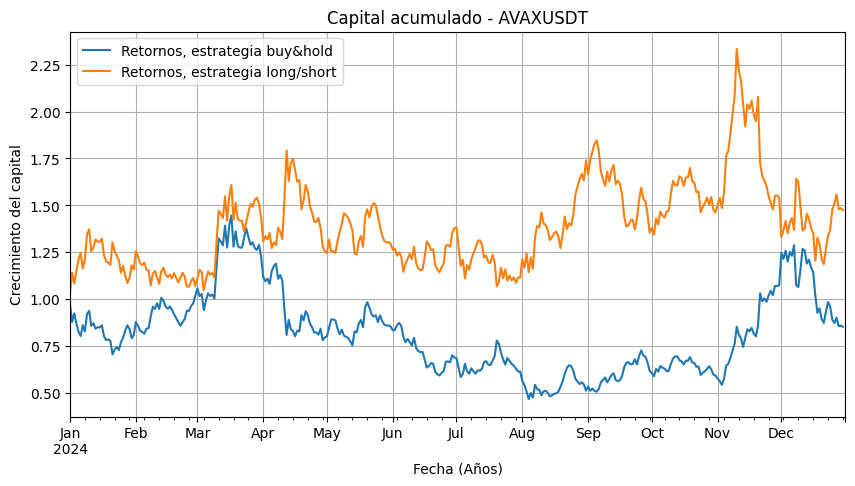

=== XRPUSDT ===
Retorno mercado    : 2.3105 (231.05%)
Retorno estrategia : 1.0943 (109.43%)



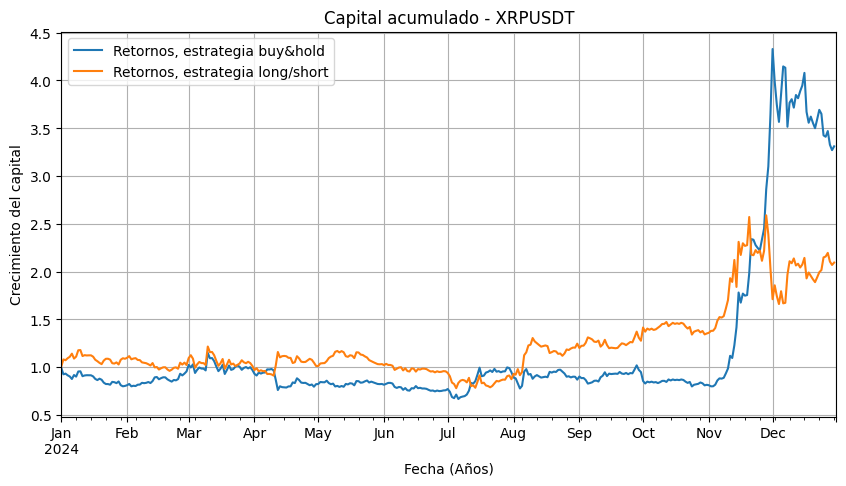

=== ADAUSDT ===
Retorno mercado    : 0.3561 (35.61%)
Retorno estrategia : -0.0225 (-2.25%)



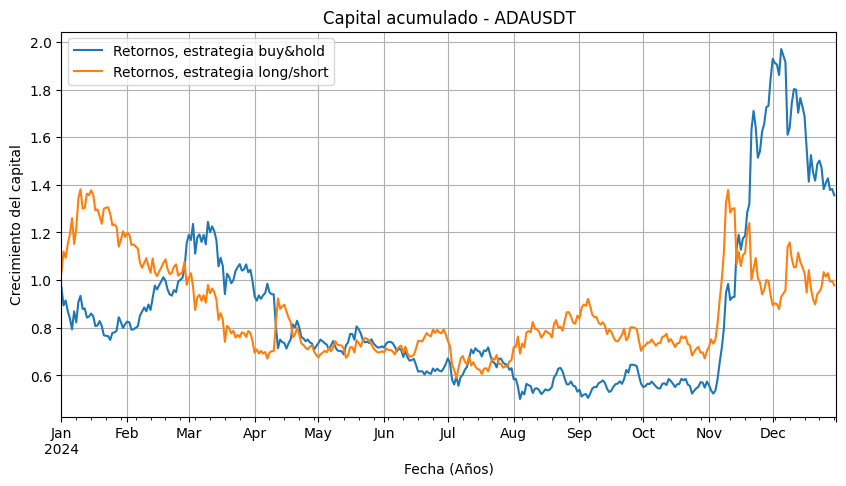

=== BTCUSDT ===
Retorno mercado    : 1.1181 (111.81%)
Retorno estrategia : -0.2970 (-29.70%)



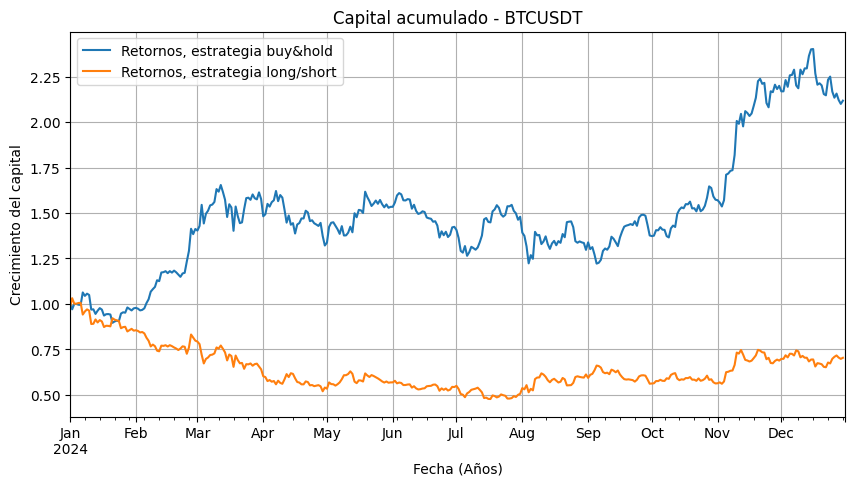

=== ETHUSDT ===
Retorno mercado    : 0.4191 (41.91%)
Retorno estrategia : 0.1773 (17.73%)



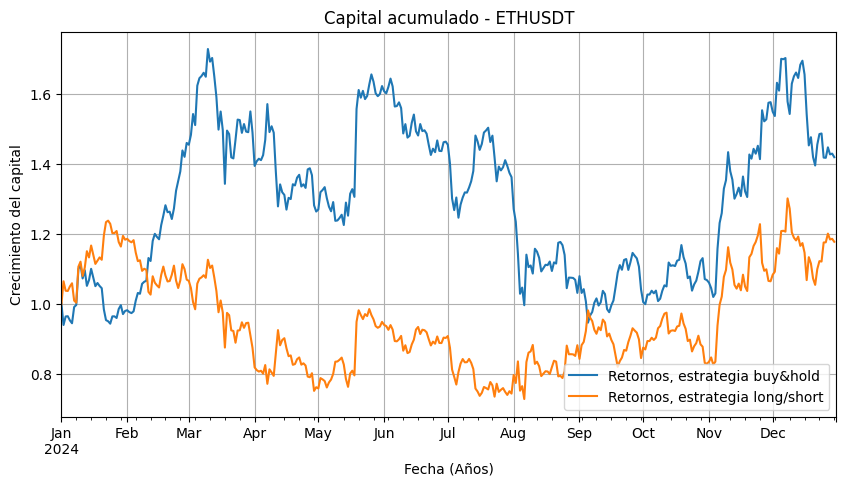

=== LINKUSDT ===
Retorno mercado    : 0.2870 (28.70%)
Retorno estrategia : -0.3565 (-35.65%)



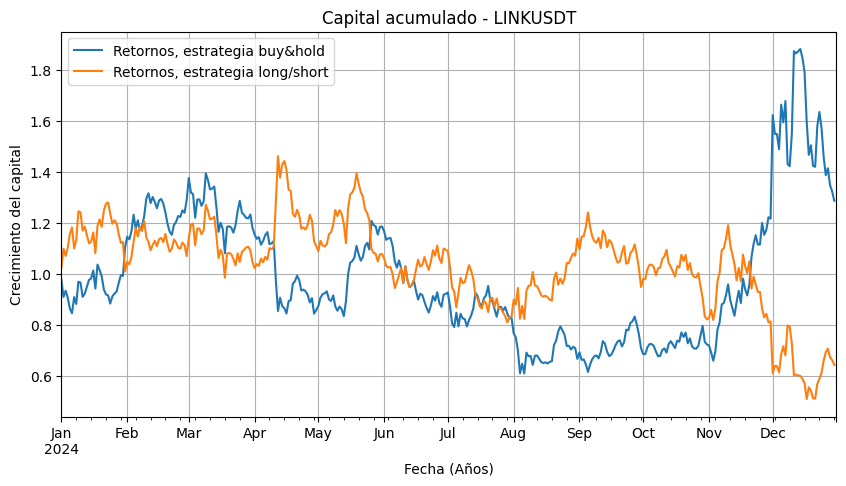

=== SOLUSDT ===
Retorno mercado    : 0.7224 (72.24%)
Retorno estrategia : 1.8872 (188.72%)



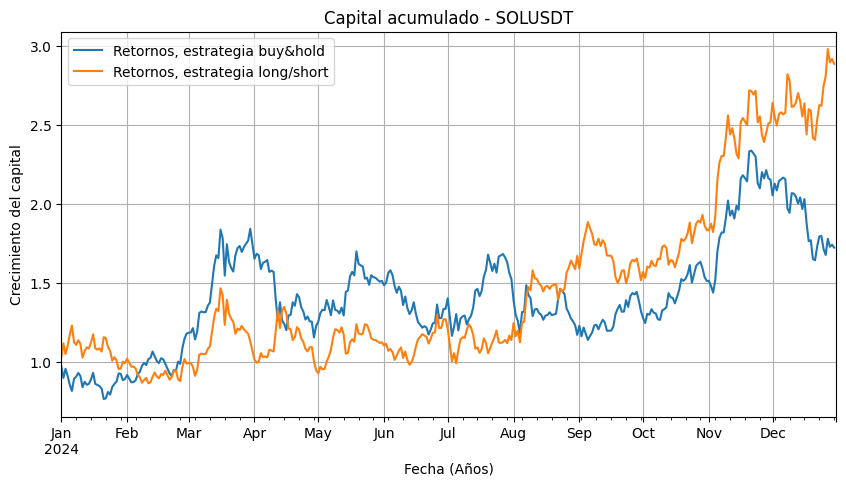

=== LTCUSDT ===
Retorno mercado    : 0.3822 (38.22%)
Retorno estrategia : 1.2783 (127.83%)



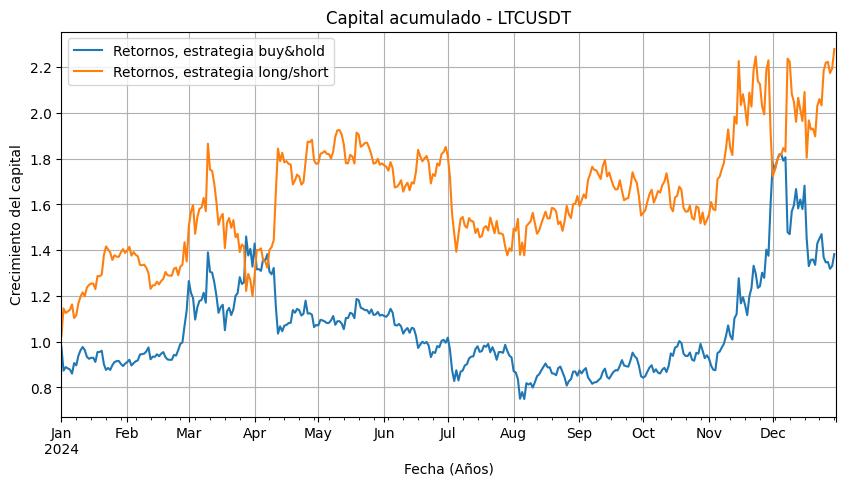

=== TRXUSDT ===
Retorno mercado    : 1.3654 (136.54%)
Retorno estrategia : -0.5945 (-59.45%)



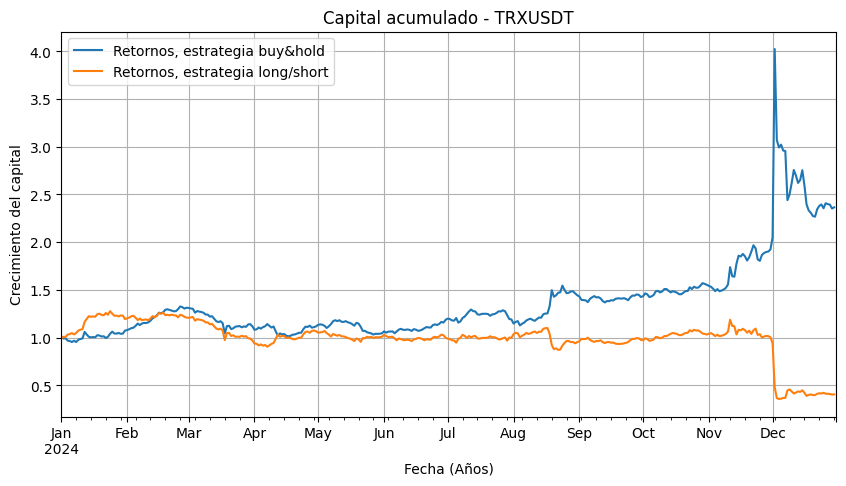

In [125]:
resultados = {}

for ric, (df, columnas) in dfs.items():
    test_start = df.index[-366]
    df = df[df.index >= test_start].copy()

    # Calcular retorno logarítmico a 7 días
    df['r_window'] = np.log(df[ric].shift(-window_pred) / df[ric])

    # Calcular 'd' solo con datos de test (ya filtrados)
    df['d'] = df_res['pred']

    #  Convertir a: 1 o -1 
    df['p'] = df['d'].map({1: 1, 0: -1})
    # / 7
    # Calcular retorno de la estrategia
    df['r_strategy'] = df['p'] * df['r_window'] 

    # Retornos acumulados (en forma natural)
    r_total = np.exp(df['r_window'].sum()) - 1
    s_total = np.exp(df['r_strategy'].sum()) - 1

    # Guardar resultados
    resultados[ric] = {
        'return_market': r_total,
        'return_strategy': s_total,
        'df': df
    }

    # Mostrar resultados
    print(f"=== {ric} ===")
    print(f"Retorno mercado    : {r_total:.4f} ({r_total * 100:.2f}%)")
    print(f"Retorno estrategia : {s_total:.4f} ({s_total * 100:.2f}%)")
    print()

    # Gráfico capital acumulado
    df[['r_window', 'r_strategy']].cumsum().apply(np.exp).plot(title=f"Capital acumulado - {ric}", figsize=(10, 5))
    plt.ylabel("Crecimiento del capital")
    plt.xlabel("Fecha (Años)")
    plt.legend(["Retornos, estrategia buy&hold", "Retornos, estrategia long/short"])
    plt.grid()
    plt.show()


=== AVAXUSDT ===
Retorno buy&hold     : -0.1485 (-14.85%)
Retorno doble umbral : 0.3381 (33.81%)



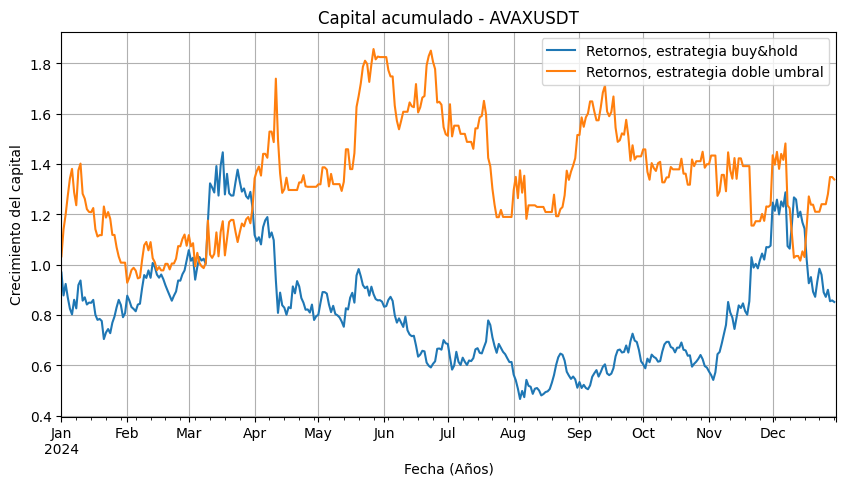

=== XRPUSDT ===
Retorno buy&hold     : 2.3105 (231.05%)
Retorno doble umbral : 0.7168 (71.68%)



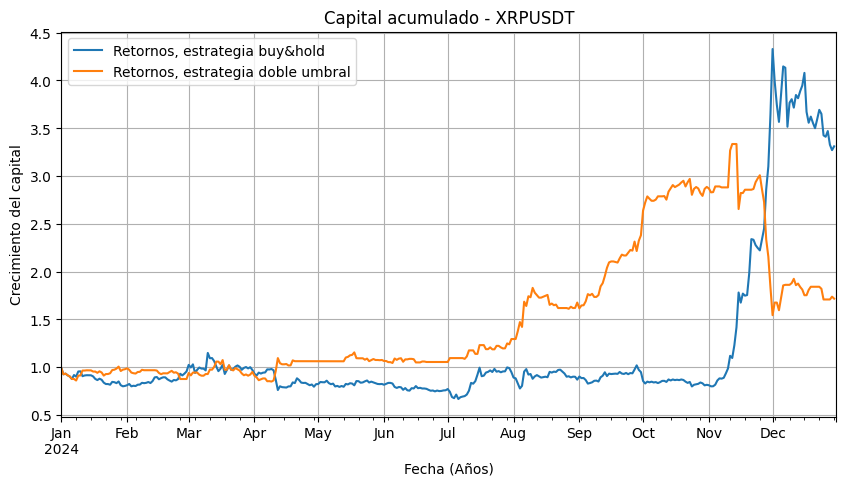

=== ADAUSDT ===
Retorno buy&hold     : 0.3561 (35.61%)
Retorno doble umbral : -0.3288 (-32.88%)



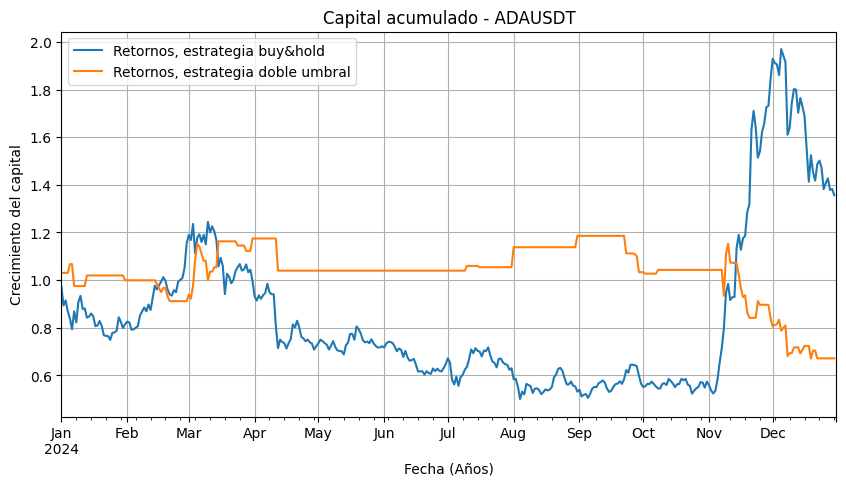

=== BTCUSDT ===
Retorno buy&hold     : 1.1181 (111.81%)
Retorno doble umbral : -0.3215 (-32.15%)



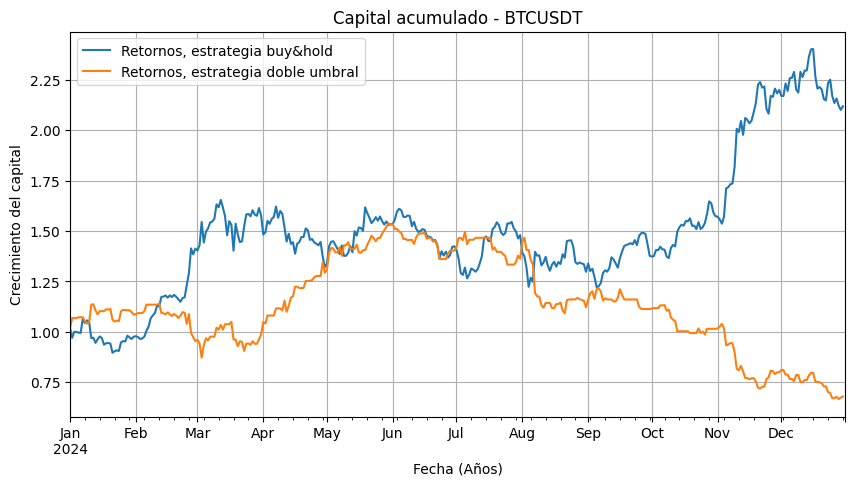

=== ETHUSDT ===
Retorno buy&hold     : 0.4191 (41.91%)
Retorno doble umbral : 0.7825 (78.25%)



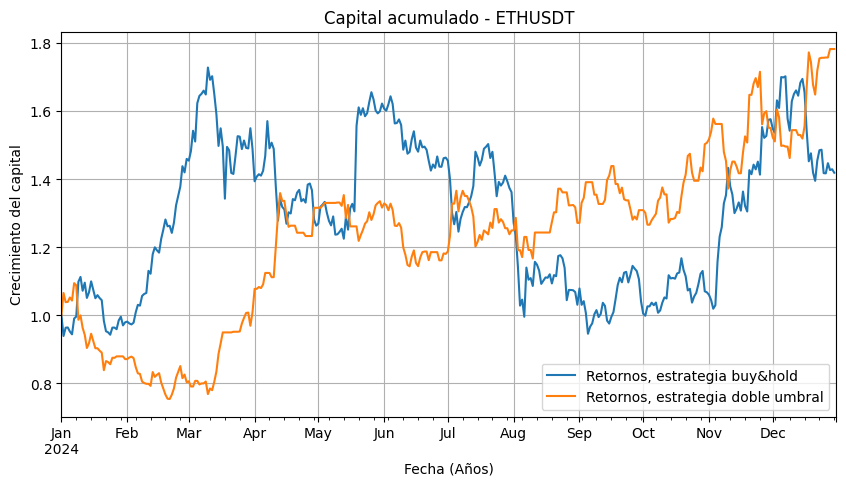

=== LINKUSDT ===
Retorno buy&hold     : 0.2870 (28.70%)
Retorno doble umbral : 3.3623 (336.23%)



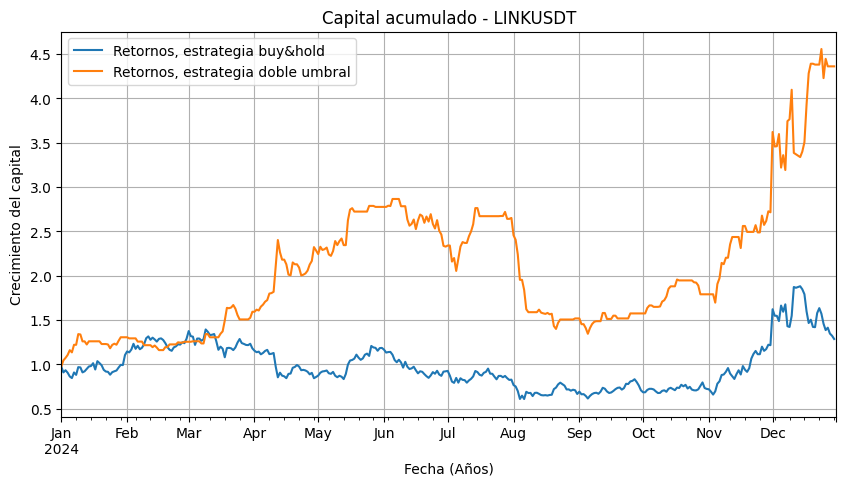

=== SOLUSDT ===
Retorno buy&hold     : 0.7224 (72.24%)
Retorno doble umbral : 2.2581 (225.81%)



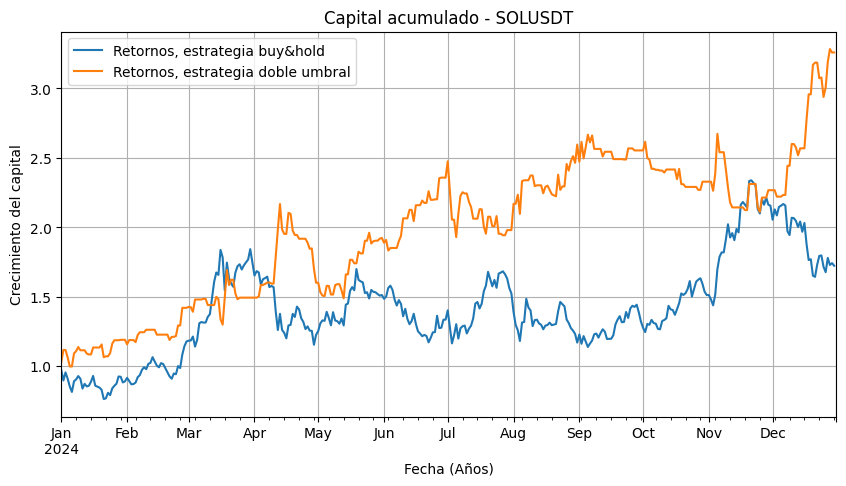

=== LTCUSDT ===
Retorno buy&hold     : 0.3822 (38.22%)
Retorno doble umbral : 0.5081 (50.81%)



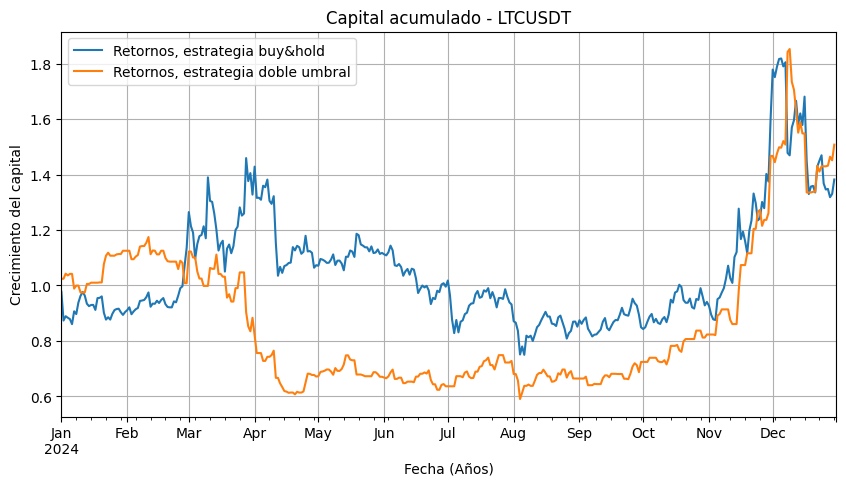

=== TRXUSDT ===
Retorno buy&hold     : 1.3654 (136.54%)
Retorno doble umbral : -0.3772 (-37.72%)



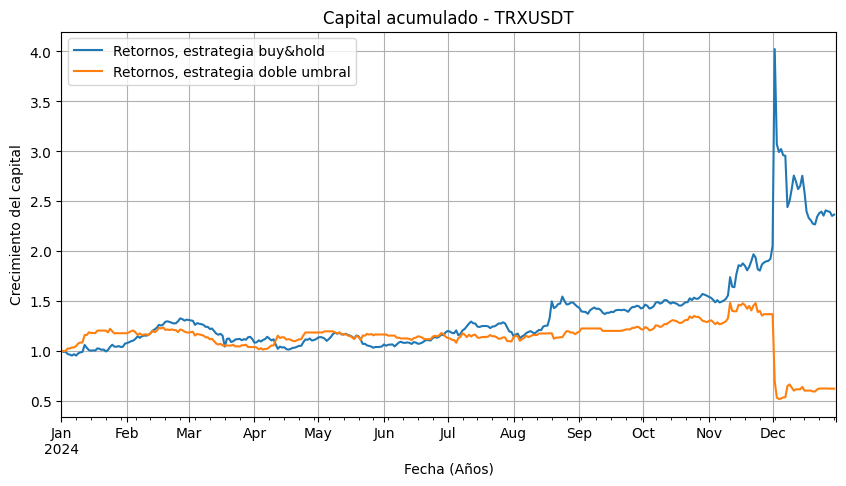

In [128]:
resultados = {}

for ric, (df, columnas) in dfs.items():
    test_start = df.index[-366]  # Último año
    df = df[df.index >= test_start].copy()

    # Calcular retorno logarítmico a 7 días
    df['r_window'] = np.log(df[ric].shift(-window_pred) / df[ric])

    # Calcular 'd' solo con datos de test (ya filtrados)
    df['d'] = df_res['pred']

    # Obtener las probabilidades del modelo
    prob_df = resultados_signals[ric].copy()
    prob_df.index = df.index  # Asegurar que coincidan los índices

    # Asignar señales basadas en umbrales
    df['prob'] = prob_df['prob']
    df['p'] = 0  # sin posición por defecto
    df.loc[df['prob'] > 0.75, 'p'] = 1
    df.loc[df['prob'] < 0.25, 'p'] = -1

    # Calcular retorno estrategia con señal de t-1 aplicada en t
    df['r_strategy'] = df['p'] * df['r_window']

    # Retornos acumulados
    r_total = np.exp(df['r_window'].sum()) - 1
    s_total = np.exp(df['r_strategy'].sum()) - 1

    # Guardar resultados
    resultados[ric] = {
        'return_market': r_total,
        'return_strategy': s_total,
        'df': df
    }

    # Mostrar resultados
    print(f"=== {ric} ===")
    print(f"Retorno buy&hold     : {r_total:.4f} ({r_total * 100:.2f}%)")
    print(f"Retorno doble umbral : {s_total:.4f} ({s_total * 100:.2f}%)")
    print()

    # Gráfico capital acumulado
    df[['r_window', 'r_strategy']].cumsum().apply(np.exp).plot(title=f"Capital acumulado - {ric}", figsize=(10, 5))
    plt.ylabel("Crecimiento del capital")
    plt.xlabel("Fecha (Años)")
    plt.legend(["Retornos, estrategia buy&hold", "Retornos, estrategia doble umbral"])
    plt.grid()
    plt.show()


=== AVAXUSDT ===
Retorno buy&hold     : -0.1485 (-14.85%)
Retorno doble umbral : 0.0694 (6.94%)



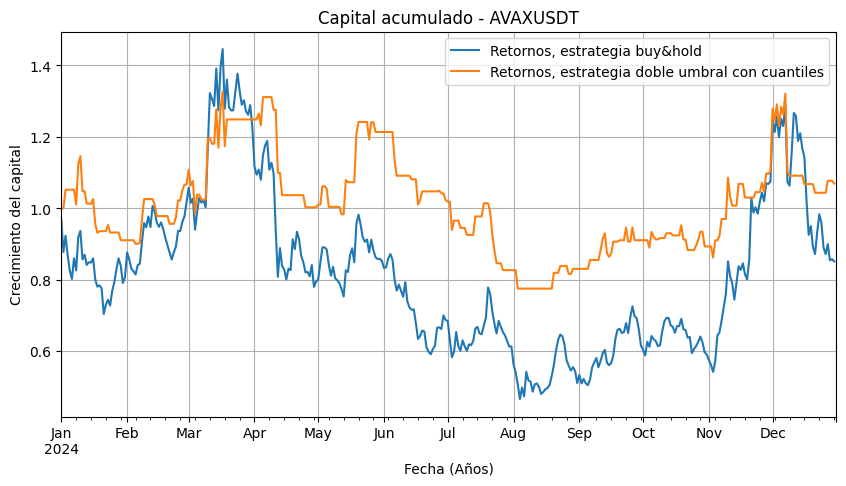

=== XRPUSDT ===
Retorno buy&hold     : 2.3105 (231.05%)
Retorno doble umbral : 1.6278 (162.78%)



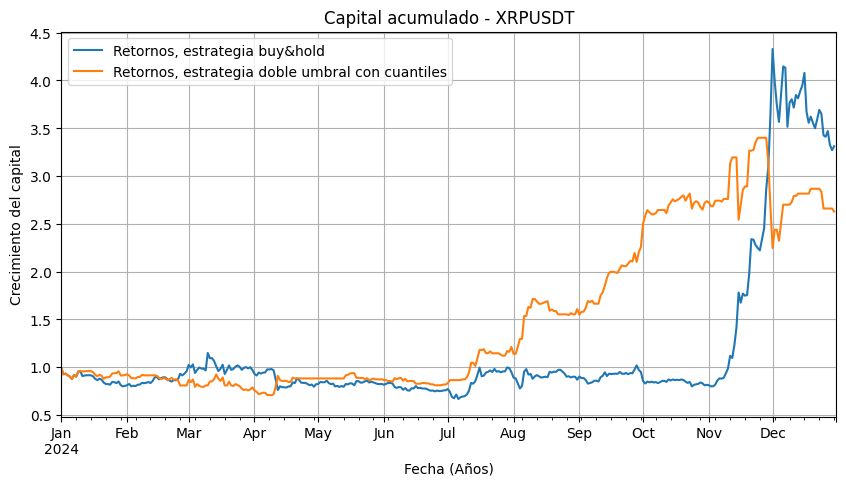

=== ADAUSDT ===
Retorno buy&hold     : 0.3561 (35.61%)
Retorno doble umbral : -0.4027 (-40.27%)



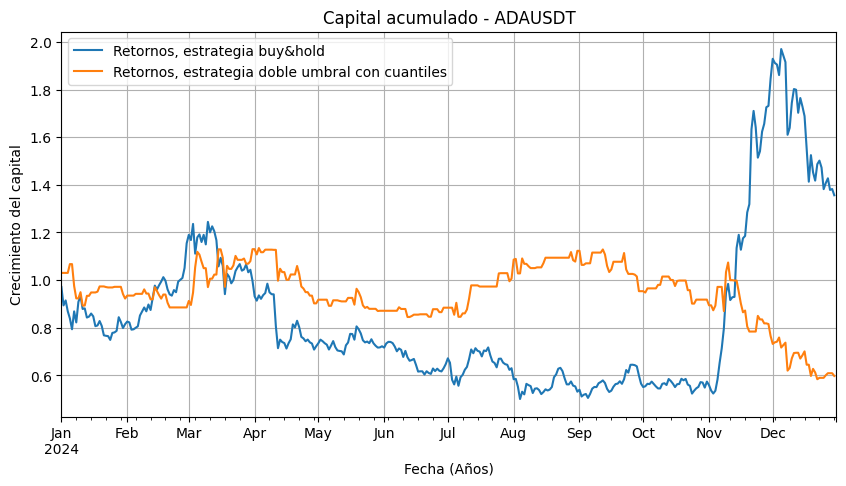

=== BTCUSDT ===
Retorno buy&hold     : 1.1181 (111.81%)
Retorno doble umbral : -0.0188 (-1.88%)



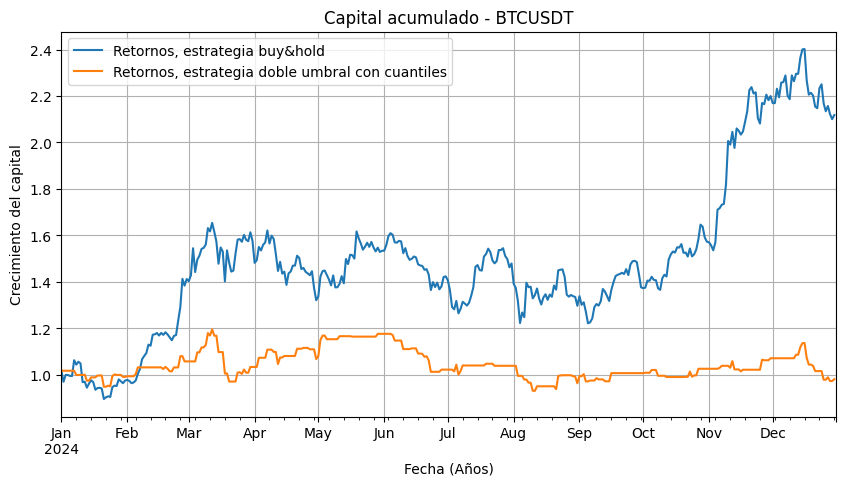

=== ETHUSDT ===
Retorno buy&hold     : 0.4191 (41.91%)
Retorno doble umbral : 1.4581 (145.81%)



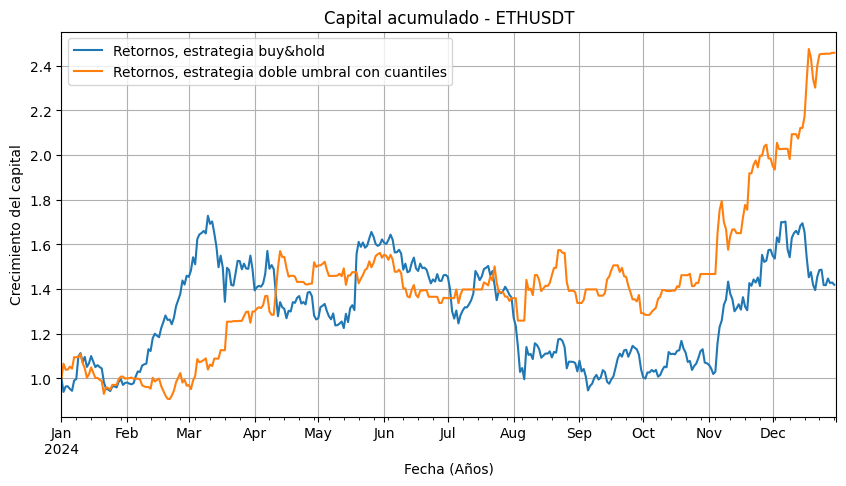

=== LINKUSDT ===
Retorno buy&hold     : 0.2870 (28.70%)
Retorno doble umbral : 5.1370 (513.70%)



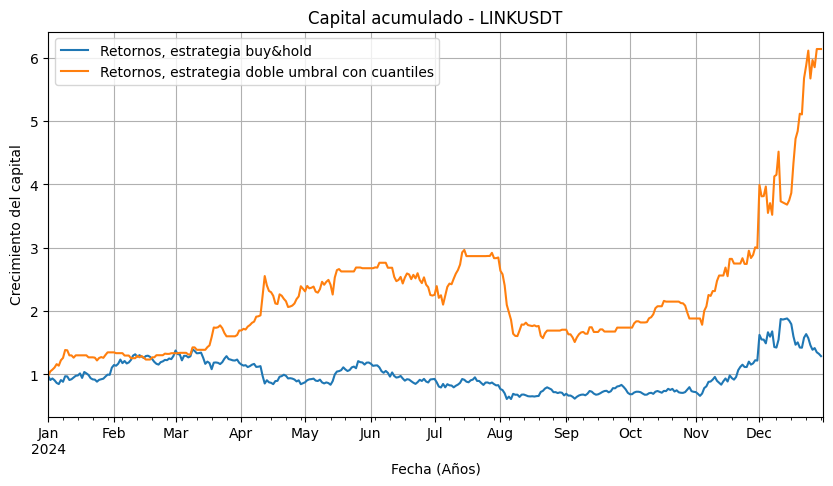

=== SOLUSDT ===
Retorno buy&hold     : 0.7224 (72.24%)
Retorno doble umbral : 2.4731 (247.31%)



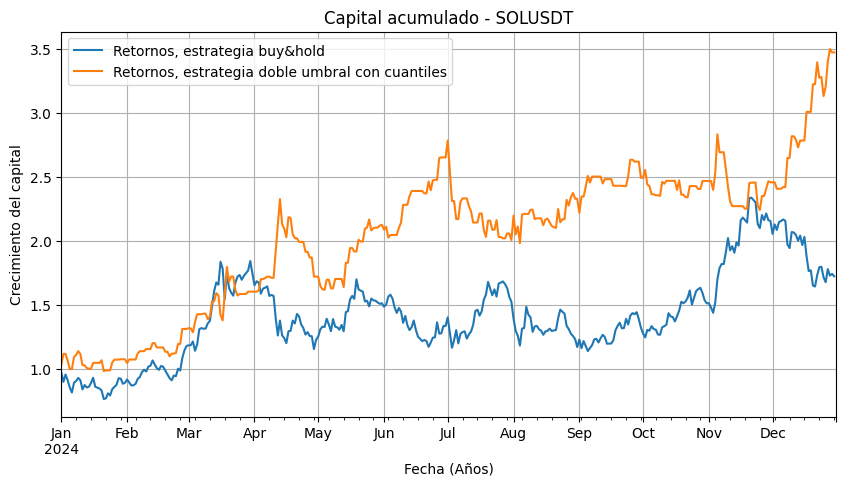

=== LTCUSDT ===
Retorno buy&hold     : 0.3822 (38.22%)
Retorno doble umbral : 0.9908 (99.08%)



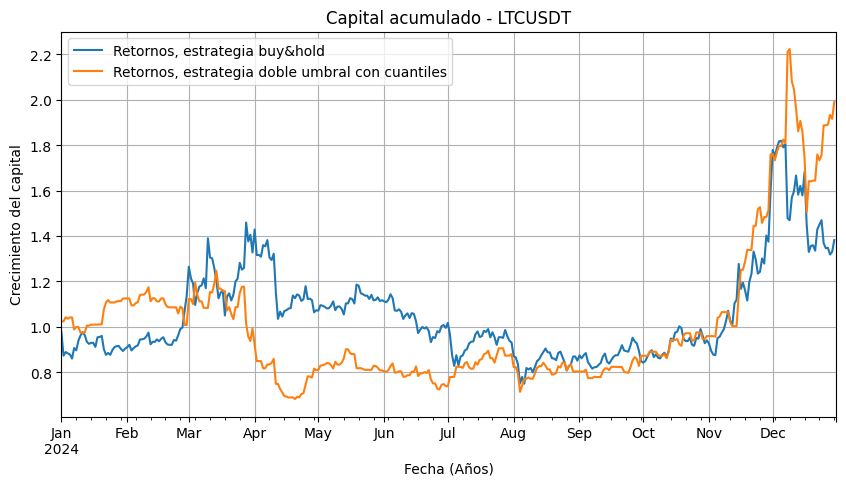

=== TRXUSDT ===
Retorno buy&hold     : 1.3654 (136.54%)
Retorno doble umbral : -0.2443 (-24.43%)



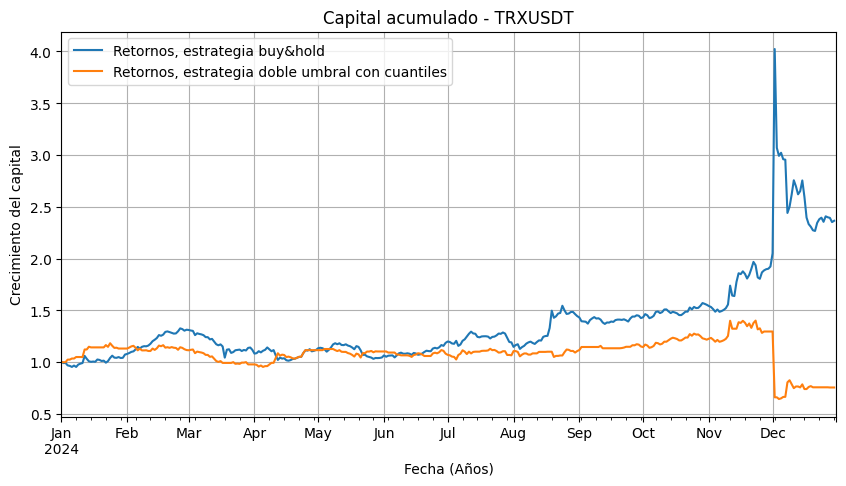

In [ ]:
resultados = {}

for ric, (df, columnas) in dfs.items():
    test_start = df.index[-366]  # Último año
    df = df[df.index >= test_start].copy()

    # Calcular retorno logarítmico a 7 días
    df['r_window'] = np.log(df[ric].shift(-window_pred) / df[ric])

    # Calcular 'd' solo con datos de test (ya filtrados)
    df['d'] = df_res['pred']

    # Obtener las probabilidades del modelo
    prob_df = resultados_signals[ric].copy()
    prob_df.index = df.index  # Asegurar que coincidan los índices

    # Asignar señales basadas en percentiles (ej. top 20%, bottom 20%)
    df['prob'] = prob_df['prob']
    upper_thresh = df['prob'].quantile(0.60)
    lower_thresh = df['prob'].quantile(0.40)

    df['p'] = 0  # sin posición por defecto
    df.loc[df['prob'] > upper_thresh, 'p'] = 1
    df.loc[df['prob'] < lower_thresh, 'p'] = -1

    # Calcular retorno estrategia con señal de t-1 aplicada en t
    df['r_strategy'] = df['p'] * df['r_window']

    # Retornos acumulados
    r_total = np.exp(df['r_window'].sum()) - 1
    s_total = np.exp(df['r_strategy'].sum()) - 1

    # Guardar resultados
    resultados[ric] = {
        'return_market': r_total,
        'return_strategy': s_total,
        'df': df
    }

    # Mostrar resultados
    print(f"=== {ric} ===")
    print(f"Retorno buy&hold     : {r_total:.4f} ({r_total * 100:.2f}%)")
    print(f"Retorno doble umbral : {s_total:.4f} ({s_total * 100:.2f}%)")
    print()

    # Gráfico capital acumulado
    df[['r_window', 'r_strategy']].cumsum().apply(np.exp).plot(title=f"Capital acumulado - {ric}", figsize=(10, 5))
    plt.ylabel("Crecimiento del capital")
    plt.xlabel("Fecha (Años)")
    plt.legend(["Retornos, estrategia buy&hold", "Retornos, estrategia doble umbral con cuantiles"])
    plt.grid()
    plt.show()
